# A minimal CPP analysis

The shortest complete loop in **AAanalysis**: load a dataset, run **Comparative Physicochemical Profiling (CPP)**, and read out the physicochemical *signature* that distinguishes the two groups.

We use the domain-level γ-secretase dataset (`DOM_GSEC`: substrates vs. non-substrates), so this is the **domain level** row of the [Prediction tasks](../index/usage_principles/prediction_tasks.html) table — the unit of comparison is the TMD part-set and the reference is built from labeled A-vs-B groups. For the broader tour (machine learning, SHAP, feature maps) see the **Quick start** tutorial.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import aaanalysis as aa
aa.options["verbose"] = False
aa.options["random_state"] = 42

## 1. Load a domain-level dataset

`load_dataset` returns a sequence table (`df_seq`) with the TMD bounds; `load_scales` returns the amino-acid scales CPP profiles over. The binary `label` column is the A-vs-B grouping CPP contrasts.

In [2]:
df_seq = aa.load_dataset(name="DOM_GSEC", n=50)
labels = df_seq["label"].to_list()
df_scales = aa.load_scales()
aa.display_df(df=df_seq, n_rows=10, show_shape=True)

DataFrame shape: (100, 8)


,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,Q14802,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0,37,59,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
2,Q86UE4,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0,50,72,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
3,Q969W9,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0,41,63,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
4,P53801,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0,97,119,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
5,Q8IUW5,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0,59,81,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE
6,P01135,MVPSAGQLALFALGI...LLKGRTACCHSETVV,0,99,121,AVVAASQKKQ,AITALVVVSIVALAVLIITCVLI,HCCQVRKHCE
7,O43914,MGGLEPCSRLLLLPL...SDVYSDLNTQRPYYK,0,42,64,DCSCSTVSPG,VLAGIVMGDLVLTVLIALAVYFL,GRLVPRGRGA
8,P05556,MNLQPIFWIGLISSV...KSAVTTVVNPKYEGK,0,729,751,ENPECPTGPD,IIPIVAGVVAGIVLIGLALLLIW,KLLMIIHDRR
9,P16234,MGTSHPAFLVLGCLL...DIGIDSSDLVEDSFL,0,527,549,VAPTLRSELT,VAAAVLVLLVIVIISLIVLVVIW,KQKPRYEIRW
10,P50895,MEPPDAPAQARGAPR...SGGARGGSGGFGDEC,0,549,571,TVSPQTSQAG,VAVMAVAVSVGLLLLVVAVFYCV,RRKGGPCCRQ


## 2. Reduce scale redundancy with AAclust

Hundreds of amino-acid scales are highly correlated. `AAclust` clusters them and keeps one representative (*medoid*) per cluster, so CPP profiles a compact, non-redundant scale set.

In [3]:
aac = aa.AAclust()
X = np.array(df_scales).T
scales = aac.fit(X, names=list(df_scales), n_clusters=50).medoid_names_
df_scales = df_scales[scales]

## 3. Run CPP

`SequenceFeature` builds the **parts** (the TMD and its juxtamembrane flanks) that CPP profiles. `CPP.run` then creates all *Part × Split × Scale* features, contrasts the two groups, and returns the ranked, non-redundant feature table `df_feat`.

In [4]:
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
cpp = aa.CPP(df_scales=df_scales, df_parts=df_parts)
df_feat = cpp.run(labels=labels)
aa.display_df(df=df_feat, n_rows=10, show_shape=True)

DataFrame shape: (100, 13)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions
1,"TMD_C_JMD_C-Seg...4,5)-ZIMJ680104",Energy,Isoelectric point,Isoelectric point,"Isoelectric poi...n et al., 1968)",0.373000,0.220000,0.220000,0.124000,0.137000,0.000000,0.000000,"33,34,35,36"
2,"TMD_C_JMD_C-Seg...6,9)-ZIMJ680104",Energy,Isoelectric point,Isoelectric point,"Isoelectric poi...n et al., 1968)",0.341000,0.264000,0.264000,0.187000,0.172000,0.000000,0.000002,"32,33"
3,"TMD-Segment(11,12)-ROBB760113",Conformation,β-turn,β-turn,"Information mea...n-Suzuki, 1976)",0.337000,0.319000,-0.319000,0.175000,0.256000,0.000000,0.000003,"27,28"
4,"TMD_C_JMD_C-Seg...2,2)-ZIMJ680104",Energy,Isoelectric point,Isoelectric point,"Isoelectric poi...n et al., 1968)",0.337000,0.106000,0.106000,0.071000,0.082000,0.000000,0.000002,"31,32,33,34,35,36,37,38,39,40"
5,"TMD_C_JMD_C-Seg...5,7)-FAUJ880103",ASA/Volume,Volume,Volume,"Normalized van ...e et al., 1988)",0.334000,0.174000,0.174000,0.109000,0.139000,0.000000,0.000002,"32,33,34"
6,"TMD_C_JMD_C-Pat...4,8)-CHOC760104",ASA/Volume,Buried,Buried,"Proportion of r...(Chothia, 1976)",0.326000,0.309000,-0.309000,0.165000,0.274000,0.000000,0.000002,"33,37"
7,"TMD_C_JMD_C-Pat...,12)-PALJ810102",Conformation,α-helix,α-helix,"Normalized freq...u et al., 1981)",0.325000,0.159000,0.159000,0.119000,0.136000,0.000000,0.000002,"24,28,32"
8,"TMD_C_JMD_C-Seg...,15)-MITS020101",Polarity,Amphiphilicity,Amphiphilicity,"Amphiphilicity ...u et al., 2002)",0.324000,0.237000,0.237000,0.174000,0.171000,0.000000,0.000002,33
9,"TMD_C_JMD_C-Pat...4,8)-GUYH850101",Composition,MPs (anchor),Partition energy,"Partition energy (Guy, 1985)",0.323000,0.242000,0.242000,0.135000,0.219000,0.000000,0.000002,"33,37"
10,"TMD_C_JMD_C-Seg...,10)-MITS020101",Polarity,Amphiphilicity,Amphiphilicity,"Amphiphilicity ...u et al., 2002)",0.323000,0.235000,0.235000,0.174000,0.171000,0.000000,0.000002,"33,34"


## 4. Rank and read out the signature

A `TreeModel` scores how much each feature contributes to telling the two groups apart (group-level *feature importance*). `CPPPlot.ranking` then shows the top features — each an interpretable, residue-grounded *Part × Split × Scale* combination — which together form the physicochemical signature of the substrates.

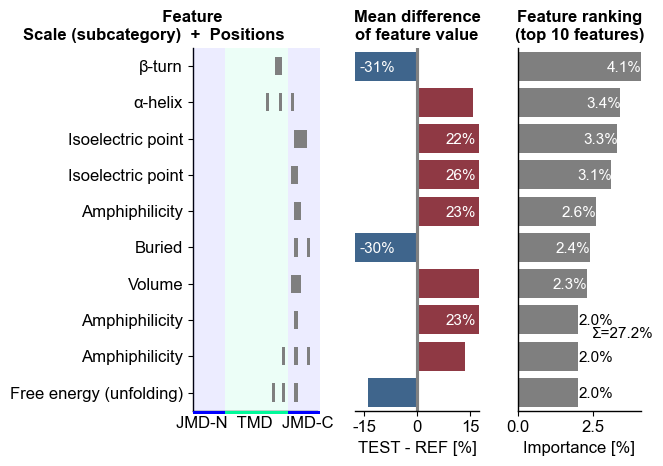

In [5]:
X = sf.feature_matrix(df_parts=df_parts, features=df_feat["feature"])
tm = aa.TreeModel()
tm.fit(X, labels=labels)
df_feat = tm.add_feat_importance(df_feat=df_feat, sort=True)

cpp_plot = aa.CPPPlot()
aa.plot_settings(short_ticks=True, weight_bold=False)
cpp_plot.ranking(df_feat=df_feat, n_top=10)
plt.tight_layout()
plt.show()

That is the whole loop: **data → CPP → signature**. To pick the right setup for *your* task — residue, domain, or protein level — see the [Prediction tasks](../index/usage_principles/prediction_tasks.html) page, and the [Protocols](../protocols.html) for end-to-end workflows.